Estimación de los parámetros $\xi,\theta, \kappa$ del modelo de Heston mediante regresión

In [1]:
import yfinance as yf
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
import numpy as np
import matplotlib.pyplot as plt

# 1. Obtener datos de AAPL
ticker = "AAPL"
df = yf.download(ticker, period="5y")

# Limpieza de columnas para yfinance
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)
df = df.dropna()

# 2. Calcular Varianza Histórica Anualizada
price_col = 'Adj Close' if 'Adj Close' in df.columns else 'Close'
log_ret = np.log(df[price_col] / df[price_col].shift(1)).dropna()
var_h = log_ret.rolling(21).var().dropna() * 252

# 3. Estimación de Parámetros de Heston
dt = 1/252
v_t_series = var_h.values[:-1]
delta_v = var_h.values[1:] - v_t_series

# Regresión para obtener kappa y theta
X = v_t_series.reshape(-1, 1)
Y = delta_v
model = LinearRegression().fit(X, Y)

# Cálculo final de parámetros
kappa = -model.coef_[0] / dt
theta = model.intercept_ / (kappa * dt)

# Estabilidad: asegurar valores positivos
kappa = max(kappa, 0.0001)
theta = max(theta, 0.0001)

# xi (Volatilidad de la volatilidad)
residuals = delta_v - model.predict(X)
xi = np.std(residuals) / np.sqrt(np.mean(v_t_series) * dt)

# rho (Correlación entre el activo y su volatilidad)
rho = np.corrcoef(log_ret.values[-len(residuals):], residuals)[0, 1]

v0 = var_h.iloc[-1] # Varianza inicial (la más reciente)

# 4. Resultados con nombres técnicos
print(f"--- Parámetros del Proceso de Volatilidad (Heston) para {ticker} ---")
print(f"κ (Velocidad de reversión): {kappa:.4f}")
print(f"θ (Varianza a largo plazo): {theta:.4f}")
print(f"ξ (Volatilidad de la volatilidad): {xi:.4f}")
print(f"ρ (Correlación precio-volatilidad): {rho:.4f}")
print(f"v0 (Varianza inicial): {v0:.4f}")

[*********************100%***********************]  1 of 1 completed

--- Parámetros del Proceso de Volatilidad (Heston) para AAPL ---
κ (Velocidad de reversión): 4.3020
θ (Varianza a largo plazo): 0.0763
ξ (Volatilidad de la volatilidad): 0.8548
ρ (Correlación precio-volatilidad): 0.1197
v0 (Varianza inicial): 0.0283


Ahora que tenemos $\kappa, \xi, \theta$, resolvemos la ecuación
$$dv_t = \kappa(\theta - v_t)dt + \xi \sqrt{v_t} dW_t$$
discretizando:
$$v_{t+1} = v_t + \kappa(\theta - v_t)\Delta t + \xi \sqrt{v_t \Delta t} Z
$$
aqui $dB=\sqrt{\Delta t} Z$ con $z\sim N(0,1)$ es lo mismo que decir $dB\sim N(0,\Delta t)$

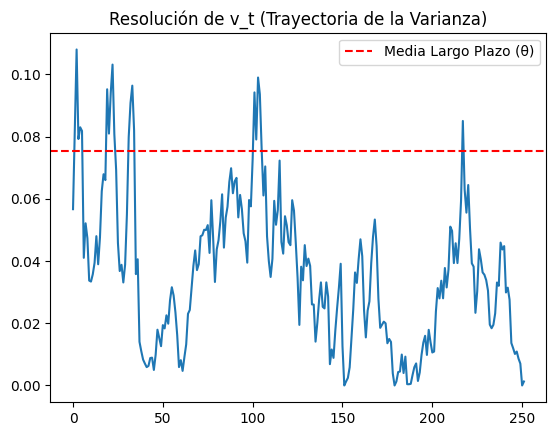

In [14]:

dt = 1/252          # Paso de tiempo (1 día)
T = 252             # Horizonte de 1 año (252 pasos)

# 1. Inicializar el vector
v_proyectada = np.zeros(T)
v_proyectada[0] = v0  # Empezamos en el valor actual de AAPL

# 2. Resolver la ecuación paso a paso (Bucle de simulación)
for t in range(1, T):
    # Generar el choque aleatorio
    Z = np.random.normal()

    # Calcular dv_t según la fórmula
    v_prev = v_proyectada[t-1]

    # drift (tendencia) + difusion (azar)
    drift = kappa * (theta - v_prev) * dt
    difusion = xi * np.sqrt(max(v_prev, 0)) * np.sqrt(dt) * Z

    # Nuevo valor = Anterior + Cambio
    # Aplicamos max(..., 0) para evitar varianzas negativas por error numérico
    v_proyectada[t] = max(v_prev + drift + difusion, 0)

# 3. Graficar el resultado
plt.plot(v_proyectada)
plt.axhline(theta, color='r', linestyle='--', label='Media Largo Plazo (θ)')
plt.title("Resolución de v_t (Trayectoria de la Varianza)")
plt.legend()
plt.show()